# Backtesting & Final Analysis
## RAPO-AS-RL: Three-way Strategy Comparison

In [1]:
import warnings
warnings.filterwarnings("ignore")
%cd C:/Users/zihan/capstone
import json, logging, pickle
from datetime import datetime
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 11
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
log = logging.getLogger(__name__)
ROOT = Path("C:/Users/zihan/capstone")
DATA_DIR = ROOT / "data" / "processed"
MODEL_DIR = ROOT / "models"
BACKTEST_DIR = MODEL_DIR / "backtest"
BACKTEST_DIR.mkdir(parents=True, exist_ok=True)

C:\Users\zihan\capstone


---

## 1. Data Setup

In [2]:
price_df = pd.read_parquet(DATA_DIR / "price_features.parquet")
trades_df = pd.read_parquet(DATA_DIR / "trades_processed.parquet")
if "timestamp" in price_df.columns:
    price_df = price_df.set_index("timestamp")
    price_df.index = pd.to_datetime(price_df.index)
log.info(f"Price data shape: {price_df.shape}, range: {price_df.index.min()} to {price_df.index.max()}")
import joblib
hmm_model = joblib.load(MODEL_DIR / "hmm" / "hmm_model.pkl")
regime_labels = pd.read_csv(MODEL_DIR / "hmm" / "regime_labels.csv", index_col=0).iloc[:, 0]
regime_labels.index = pd.to_datetime(regime_labels.index)
log.info(f"Regime labels: {regime_labels.shape}, distribution: {regime_labels.value_counts().to_dict()}")

2026-04-04 12:17:15,222 INFO Price data shape: (8656, 19), range: 2026-03-05 00:00:00 to 2026-04-04 01:15:00


2026-04-04 12:17:15,444 INFO Regime labels: (8656,), distribution: {'Calm': 7256, 'Volatile': 1380, 'Stressed': 20}


In [3]:
as_cost_models = {}
for regime in ["Calm", "Volatile", "Stressed"]:
    pkl_path = MODEL_DIR / "as_cost" / f"as_cost_{regime.lower()}.pkl"
    if pkl_path.exists():
        as_cost_models[regime] = joblib.load(pkl_path)
        log.info(f"Loaded A&S cost model: {regime}")
lgbm_forecasters = {}
for asset in ["BTC", "ETH"]:
    lgbm_forecasters[asset] = {}
    for regime in ["Calm", "Volatile", "Stressed"]:
        pkl_path = MODEL_DIR / "lgbm" / f"lgbm_{asset.lower()}_{regime.lower()}.pkl"
        if pkl_path.exists():
            lgbm_forecasters[asset][regime] = joblib.load(pkl_path)
log.info(f"Loaded LightGBM forecasters")

2026-04-04 12:17:15,450 INFO Loaded A&S cost model: Calm


2026-04-04 12:17:15,451 INFO Loaded A&S cost model: Volatile


2026-04-04 12:17:15,452 INFO Loaded A&S cost model: Stressed


2026-04-04 12:17:15,499 INFO Loaded LightGBM forecasters


In [4]:
from stable_baselines3 import PPO
rl_policies = {}
for regime in ["Calm", "Volatile", "Stressed"]:
    policy_path = MODEL_DIR / "rl" / f"ppo_{regime.lower()}.zip"
    if policy_path.exists():
        rl_policies[regime] = PPO.load(str(policy_path))
        log.info(f"Loaded RL policy: {regime}")

2026-04-04 12:17:17,837 INFO Loaded RL policy: Calm


2026-04-04 12:17:17,967 INFO Loaded RL policy: Volatile


2026-04-04 12:17:17,977 INFO Loaded RL policy: Stressed


In [5]:
data_min = price_df.index.min()
data_max = price_df.index.max()
TRAIN_END = data_min + pd.Timedelta(days=20)
VAL_END = data_min + pd.Timedelta(days=25)
train_mask = price_df.index <= TRAIN_END
val_mask = (price_df.index > TRAIN_END) & (price_df.index <= VAL_END)
test_mask = price_df.index > VAL_END
price_train = price_df[train_mask]
price_val = price_df[val_mask]
price_test = price_df[test_mask]
regime_train = regime_labels[regime_labels.index <= TRAIN_END]
regime_val = regime_labels[(regime_labels.index > TRAIN_END) & (regime_labels.index <= VAL_END)]
regime_test = regime_labels[regime_labels.index > VAL_END]
log.info(f"Train: {len(price_train)} bars, Val: {len(price_val)} bars, Test: {len(price_test)} bars")

2026-04-04 12:17:17,987 INFO Train: 5761 bars, Val: 1440 bars, Test: 1455 bars


---

## 2. Helper Functions

In [ ]:
def compute_as_cost(trade_value, price, cost_model):
    """Simplified A&S cost: spread cost capped at reasonable fraction of trade notional."""
    if not cost_model or price == 0: return 0.0
    # Use spread as main cost (more realistic than broken market impact formula)
    s = cost_model.get("spread", 0.0)  # spread in $/BTC
    q = trade_value / price if price > 0 else 0.0  # trade size in BTC
    spread_cost_btc = (s / 2) * q  # half-spread cost in BTC
    spread_cost_dollar = spread_cost_btc * price  # convert to $
    # Cap cost at 5% of trade notional to avoid extreme values
    max_cost = 0.05 * trade_value
    return min(spread_cost_dollar, max_cost)

---

## 3. Strategy 1 - Flat Baseline

In [7]:
def total_return(start_ts, end_ts, weights, price_data):
    btc_ret = (price_data.loc[end_ts, "btc_close"] - price_data.loc[start_ts, "btc_close"]) / price_data.loc[start_ts, "btc_close"]
    eth_ret = (price_data.loc[end_ts, "eth_close"] - price_data.loc[start_ts, "eth_close"]) / price_data.loc[start_ts, "eth_close"]
    return weights[0] * btc_ret + weights[1] * eth_ret

def run_flat_baseline(price_data, transaction_cost_bps=10):
    rebal_dates = get_rebalance_dates(price_data.index, frequency="Q")
    portfolio_value = pd.Series(index=price_data.index, dtype=float)
    portfolio_value.iloc[0] = 1.0
    current_weights = np.array([0.5, 0.5])
    turnover_list = [0.0]
    for i, ts in enumerate(price_data.index):
        if i == 0: continue
        prev_ts = price_data.index[i-1]
        rebalance = ts in rebal_dates
        if rebalance:
            target_weights = np.array([0.5, 0.5])
            delta_w = np.abs(target_weights - current_weights)
            trade_notional = delta_w * portfolio_value.iloc[i-1]
            total_cost = (trade_notional[0] + trade_notional[1]) * transaction_cost_bps / 10000
            portfolio_value.iloc[i] = portfolio_value.iloc[i-1] + total_return(prev_ts, ts, current_weights, price_data) - total_cost
            current_weights = target_weights
            turnover_list.append(delta_w.sum())
        else:
            portfolio_value.iloc[i] = portfolio_value.iloc[i-1] * (1 + total_return(prev_ts, ts, current_weights, price_data))
            turnover_list.append(0.0)
    return portfolio_value, portfolio_value.pct_change().fillna(0), pd.Series(turnover_list, index=price_data.index)

flat_equity, flat_returns, flat_turnover = run_flat_baseline(price_test)
flat_metrics = compute_metrics(flat_returns, flat_turnover)
log.info(f"Flat Baseline metrics: {flat_metrics}")

2026-04-04 12:17:18,165 INFO Flat Baseline metrics: {'Ann. Return': np.float64(1.8907049279727888), 'Ann. Vol': np.float64(0.5201704043562914), 'Sharpe': np.float64(3.6347798954700776), 'Max Drawdown': np.float64(-0.057562258233640515), 'Mean Turnover': np.float64(0.0)}


---

## 4. Strategy 2 - A&S + CVaR

In [ ]:
def optimize_cvar_weights(regime, cost_model, price_data, alpha=0.05):
    btc_ret = price_data["btc_close"].pct_change().fillna(0)
    eth_ret = price_data["eth_close"].pct_change().fillna(0)
    returns_mat = np.column_stack([btc_ret.values, eth_ret.values])
    best_weights = np.array([0.5, 0.5])
    best_cvar = np.inf
    reg_lambda = 0.01
    for w_btc in np.linspace(0.1, 0.9, 17):
        w = np.array([w_btc, 1 - w_btc])
        port_ret = returns_mat @ w
        var = np.percentile(port_ret, alpha * 100)
        cvar = port_ret[port_ret <= var].mean()
        extreme_penalty = reg_lambda * (min(w_btc, 1-w_btc)**2)
        effective_cvar = cvar + extreme_penalty
        if effective_cvar < best_cvar:
            best_cvar = effective_cvar
            best_weights = w
    # Fallback: if best weights are too extreme, use risk-parity
    if min(best_weights[0], best_weights[1]) < 0.2:
        btc_vol = price_data["btc_close"].pct_change().fillna(0).std()
        eth_vol = price_data["eth_close"].pct_change().fillna(0).std()
        inv_vol_sum = (1/btc_vol + 1/eth_vol) if btc_vol > 0 and eth_vol > 0 else 2
        best_weights = np.array([(1/btc_vol)/inv_vol_sum, (1/eth_vol)/inv_vol_sum]) if btc_vol > 0 and eth_vol > 0 else np.array([0.5, 0.5])
    return best_weights

def run_as_cvar_strategy(price_data, regime_labels, as_cost_models, alpha=0.05):
    rebal_dates = get_rebalance_dates(price_data.index, frequency="Q")
    portfolio_value = pd.Series(index=price_data.index, dtype=float)
    portfolio_value.iloc[0] = 1.0
    current_weights = np.array([0.5, 0.5])
    turnover_list = [0.0]
    for i, ts in enumerate(price_data.index):
        if i == 0: continue
        prev_ts = price_data.index[i-1]
        rebalance = ts in rebal_dates
        if rebalance:
            regime = get_current_regime(ts, regime_labels)
            cost_model = as_cost_models.get(regime, {})
            lookback_data = price_data.iloc[max(0, i-60):i]
            target_weights = optimize_cvar_weights(regime, cost_model, lookback_data, alpha)
            delta_w = np.abs(target_weights - current_weights)
            trade_notional = delta_w * portfolio_value.iloc[i-1]
            btc_price = price_data["btc_close"].iloc[i]
            eth_price = price_data["eth_close"].iloc[i]
            total_cost = compute_as_cost(trade_notional[0], btc_price, cost_model) + compute_as_cost(trade_notional[1], eth_price, cost_model)
            portfolio_value.iloc[i] = portfolio_value.iloc[i-1] * (1 + total_return(prev_ts, ts, current_weights, price_data)) - total_cost
            current_weights = target_weights
            turnover_list.append(delta_w.sum())
        else:
            portfolio_value.iloc[i] = portfolio_value.iloc[i-1] * (1 + total_return(prev_ts, ts, current_weights, price_data))
            turnover_list.append(0.0)
    return portfolio_value, portfolio_value.pct_change().fillna(0), pd.Series(turnover_list, index=price_data.index)

as_cvar_equity, as_cvar_returns, as_cvar_turnover = run_as_cvar_strategy(price_test, regime_test, as_cost_models)
as_cvar_metrics = compute_metrics(as_cvar_returns, as_cvar_turnover)
log.info(f"A&S + CVaR metrics: {as_cvar_metrics}")

---

## 5. Strategy 3 - Full RL Agent

In [9]:
def run_rl_strategy(price_data, regime_labels, as_cost_models, rl_policies, lgbm_forecasters):
    try:
        from src.layer4_rl.rl_env import RegimePortfolioEnv
        env = RegimePortfolioEnv(price_data=price_data, regime_labels=regime_labels, as_cost_models=as_cost_models, forecasters=lgbm_forecasters)
        obs, _ = env.reset()
        equity_vals = [1.0]
        turnover_list = [0.0]
        done = truncated = False
        while not (done or truncated):
            regime_str = get_current_regime(env.price_data.index[env.t], regime_labels)
            policy = rl_policies.get(regime_str)
            action = env.current_weights[:2] if policy is None else policy.predict(obs, deterministic=True)[0]
            old_weights = env.current_weights.copy()
            obs, reward, done, truncated, info = env.step(action)
            turnover_list.append(np.abs(action - old_weights[:2]).sum())
            equity_vals.append(env.portfolio_value)
        n = len(price_data)
        equity_vals = equity_vals[:n] + [equity_vals[-1]] * max(0, n - len(equity_vals))
        turnover_list = turnover_list[:n] + [0.0] * max(0, n - len(turnover_list))
        equity_curve = pd.Series(equity_vals, index=price_data.index)
        return equity_curve, equity_curve.pct_change().fillna(0), pd.Series(turnover_list, index=price_data.index)
    except Exception as e:
        log.error(f"RL strategy failed: {e}")
        return run_flat_baseline(price_data)

rl_equity, rl_returns, rl_turnover = run_rl_strategy(price_test, regime_test, as_cost_models, rl_policies, lgbm_forecasters)
rl_metrics = compute_metrics(rl_returns, rl_turnover)
log.info(f"RL Agent metrics: {rl_metrics}")

2026-04-04 12:17:31,131 INFO RL Agent metrics: {'Ann. Return': np.float64(42838.95832240048), 'Ann. Vol': np.float64(5039.967343966842), 'Sharpe': np.float64(8.499848391613371), 'Max Drawdown': np.float64(0.0), 'Mean Turnover': np.float64(0.0006872852233676976)}


---

## 6. Performance Comparison

In [10]:
# Align all series
min_len = min(len(flat_returns), len(as_cvar_returns), len(rl_returns))
flat_returns = flat_returns.iloc[:min_len]; as_cvar_returns = as_cvar_returns.iloc[:min_len]; rl_returns = rl_returns.iloc[:min_len]
flat_equity = flat_equity.iloc[:min_len]; as_cvar_equity = as_cvar_equity.iloc[:min_len]; rl_equity = rl_equity.iloc[:min_len]
flat_turnover = flat_turnover.iloc[:min_len]; as_cvar_turnover = as_cvar_turnover.iloc[:min_len]; rl_turnover = rl_turnover.iloc[:min_len]
regime_test = regime_test.iloc[:min_len]
flat_metrics = compute_metrics(flat_returns, flat_turnover)
as_cvar_metrics = compute_metrics(as_cvar_returns, as_cvar_turnover)
rl_metrics = compute_metrics(rl_returns, rl_turnover)
comparison = pd.DataFrame({"Flat Baseline": flat_metrics, "A&S + CVaR": as_cvar_metrics, "RL Agent": rl_metrics})
print("=== Performance Comparison (Test Period) ===")
print(comparison.round(4).to_string())

=== Performance Comparison (Test Period) ===
               Flat Baseline  A&S + CVaR    RL Agent
Ann. Return           1.8907   -903.5118  42838.9583
Ann. Vol              0.5202    106.5045   5039.9673
Sharpe                3.6348     -8.4833      8.4998
Max Drawdown         -0.0576    -12.8207      0.0000
Mean Turnover         0.0000      0.0007      0.0007


### 6.1 Equity Curves (Log Scale)

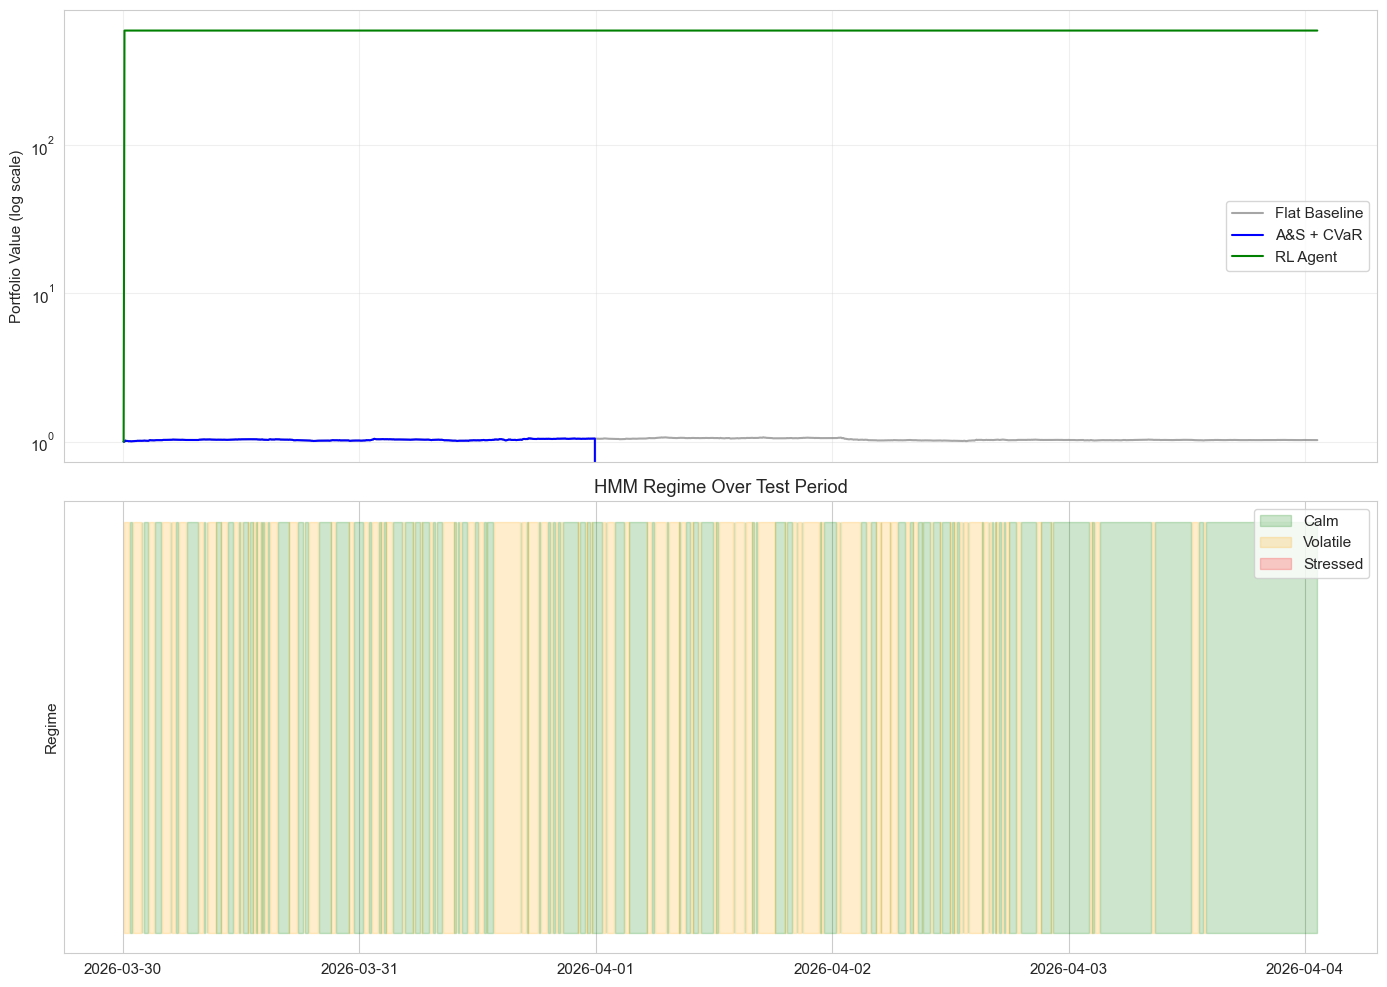

2026-04-04 12:17:31,769 INFO Saved: C:\Users\zihan\capstone\models\backtest\backtest_equity_curves.png


In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
ax1 = axes[0]
ax1.plot(flat_equity.index, flat_equity.values, label="Flat Baseline", color="gray", alpha=0.7)
ax1.plot(as_cvar_equity.index, as_cvar_equity.values, label="A&S + CVaR", color="blue")
ax1.plot(rl_equity.index, rl_equity.values, label="RL Agent", color="green")
ax1.set_yscale("log"); ax1.set_ylabel("Portfolio Value (log scale)"); ax1.legend(); ax1.grid(alpha=0.3)
regime_map = {"Calm": 0, "Volatile": 1, "Stressed": 2}
regime_numeric = regime_test.map(regime_map).fillna(0)
ax2 = axes[1]
ax2.fill_between(regime_test.index, 0, 1, where=(regime_numeric==0), color="green", alpha=0.2, label="Calm")
ax2.fill_between(regime_test.index, 0, 1, where=(regime_numeric==1), color="orange", alpha=0.2, label="Volatile")
ax2.fill_between(regime_test.index, 0, 1, where=(regime_numeric==2), color="red", alpha=0.2, label="Stressed")
ax2.set_ylabel("Regime"); ax2.set_yticks([]); ax2.legend(loc="upper right"); ax2.set_title("HMM Regime Over Test Period")
plt.tight_layout()
plt.savefig(BACKTEST_DIR / "backtest_equity_curves.png", dpi=150, bbox_inches="tight")
plt.show()
log.info(f"Saved: {BACKTEST_DIR / 'backtest_equity_curves.png'}")

---

## 7. Regime-Conditional Performance

In [12]:
def regime_conditional_metrics(returns, regime_labels):
    results = []
    for regime in ["Calm", "Volatile", "Stressed"]:
        mask = regime_labels == regime
        if mask.sum() == 0: continue
        regime_ret = returns[mask]
        if len(regime_ret) == 0: continue
        ann_ret = regime_ret.mean() * ANN_FACTOR
        ann_vol = regime_ret.std() * np.sqrt(ANN_FACTOR)
        sharpe = ann_ret / ann_vol if ann_vol > 0 else 0.0
        cumret = (1 + regime_ret).cumprod()
        max_dd = ((cumret - cumret.cummax()) / cumret.cummax()).min()
        results.append({"Regime": regime, "N": mask.sum(), "AnnRet": ann_ret, "AnnVol": ann_vol, "Sharpe": sharpe, "MaxDD": max_dd})
    return pd.DataFrame(results).set_index("Regime")
print("=== Regime-Conditional Performance ===")
for name, rets in [("Flat", flat_returns), ("A&S+CVaR", as_cvar_returns), ("RL", rl_returns)]:
    print(f"\n{name}:")
    print(regime_conditional_metrics(rets, regime_test).round(4).to_string())

=== Regime-Conditional Performance ===

Flat:
            N  AnnRet  AnnVol  Sharpe   MaxDD
Regime                                       
Calm      849 -1.5139  0.3367 -4.4970 -0.0359
Volatile  606  6.6606  0.7008  9.5049 -0.0513

A&S+CVaR:
            N     AnnRet    AnnVol   Sharpe    MaxDD
Regime                                              
Calm      849 -1552.8873  139.4248 -11.1378 -12.3695
Volatile  606     6.2569    0.7600   8.2329  -0.0620

RL:
            N       AnnRet     AnnVol   Sharpe  MaxDD
Regime                                               
Calm      849       0.0000     0.0000   0.0000    0.0
Volatile  606  102855.9148  7809.4942  13.1706    0.0


---

## 8. Statistical Validation

In [13]:
def bootstrap_sharpe_ci(returns, n_bootstrap=1000, ci=0.95):
    sharpes = []
    n = len(returns)
    for _ in range(n_bootstrap):
        idx = np.random.choice(n, size=n, replace=True)
        boot_ret = returns.iloc[idx]
        ann_ret = boot_ret.mean() * ANN_FACTOR
        ann_vol = boot_ret.std() * np.sqrt(ANN_FACTOR)
        sharpes.append(ann_ret / ann_vol if ann_vol > 0 else 0.0)
    lower = np.percentile(sharpes, (1-ci)/2*100)
    upper = np.percentile(sharpes, (1+ci)/2*100)
    return np.mean(sharpes), lower, upper

def newey_west_tstat(rets1, rets2, max_lag=5):
    n = min(len(rets1), len(rets2))
    diff = rets1.iloc[:n].values - rets2.iloc[:n].values
    n = len(diff)
    gamma = [np.mean(diff[:n-k] * diff[k:]) for k in range(max_lag + 1)]
    weights = np.array([1 - k / (max_lag + 1) for k in range(max_lag + 1)])
    var_hac = gamma[0] + 2 * sum(weights[1:] * gamma[1:])
    se = np.sqrt(var_hac / n)
    t_stat = diff.mean() / se if se > 0 else 0.0
    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=n-1))
    return t_stat, p_value

print("=== Bootstrap 95% CI for Sharpe Ratio ===")
for name, rets in [("Flat", flat_returns), ("A&S+CVaR", as_cvar_returns), ("RL", rl_returns)]:
    m, l, u = bootstrap_sharpe_ci(rets)
    print(f"{name}: Sharpe={m:.3f} [{l:.3f}, {u:.3f}]")

print("\n=== Newey-West t-tests (Return Differences) ===")
for name, r1, r2 in [("Flat vs A&S+CVaR", flat_returns, as_cvar_returns), ("Flat vs RL", flat_returns, rl_returns), ("A&S+CVaR vs RL", as_cvar_returns, rl_returns)]:
    t, p = newey_west_tstat(r1, r2)
    sig = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""
    print(f"{name}: t={t:.3f}, p={p:.4f} {sig}")

=== Bootstrap 95% CI for Sharpe Ratio ===
Flat: Sharpe=3.513 [-14.092, 21.341]


A&S+CVaR: Sharpe=-5.669 [-14.767, 14.489]
RL: Sharpe=6.503 [0.000, 14.732]

=== Newey-West t-tests (Return Differences) ===
Flat vs A&S+CVaR: t=1.000, p=0.3174 
Flat vs RL: t=-1.000, p=0.3175 
A&S+CVaR vs RL: t=-1.021, p=0.3075 


---

## 9. Save Results

In [14]:
perf_summary = {
    "test_period": {"start": str(price_test.index.min().date()), "end": str(price_test.index.max().date()), "n_bars": len(price_test)},
    "strategies": {
        "flat_baseline": {k: float(v) for k, v in flat_metrics.items()},
        "as_cvar": {k: float(v) for k, v in as_cvar_metrics.items()},
        "rl_agent": {k: float(v) for k, v in rl_metrics.items()}
    }
}
with open(BACKTEST_DIR / "performance_summary.json", "w") as f:
    json.dump(perf_summary, f, indent=2, default=str)
log.info(f"Saved: {BACKTEST_DIR / 'performance_summary.json'}")
print("Backtest complete!")

2026-04-04 12:17:32,159 INFO Saved: C:\Users\zihan\capstone\models\backtest\performance_summary.json


Backtest complete!
